In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
from funcs import cross_sec_lon, cross_sec_lon_prob, cross_sec_lon_prob2, calc_pv, method34

In [10]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to contain the relevant features
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]','Profile_Number']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month','Profile_Number']]

# # Calculate potential vorticity
# df_ST = calc_pv(df_ST)

In [11]:
# Define random master seed for reproducibility
master_seed = 22
random.seed(master_seed)

# Ensemble size
ensemble_size = 10

# Define a list of random seeds
seeds = random.sample(range(1, 10000), ensemble_size)

In [12]:
# Define features to use for clustering
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']
# features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Pv']

In [13]:
df_sampled = method34(df=df_ST, seed=master_seed)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:956: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [14]:
# Do BIC and AIC calculation for different number of clusters and for 10 different seeds
all_scores = {}
all_aic_scores = {}
n_components_range = range(1, 8)
for i,seed in enumerate(seeds):
    bic_scores = [] 
    aic_scores = []
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
        gmm.fit(df_sampled[features])
        bic_scores.append(gmm.bic(df_sampled[features]))
        aic_scores.append(gmm.aic(df_sampled[features]))

    all_scores[i] = bic_scores
    all_aic_scores[i] = aic_scores

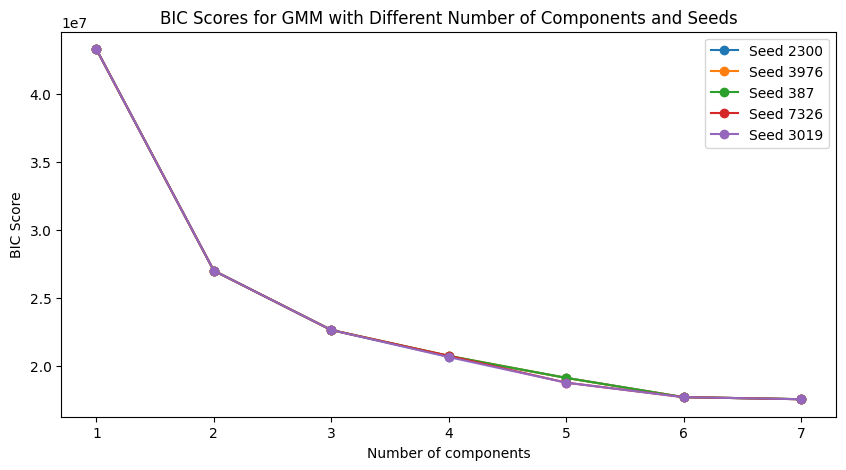

In [15]:
plt.figure(figsize=(10,5))
for i in range(ensemble_size):
    plt.plot(n_components_range, all_scores[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components and Seeds')
plt.legend()

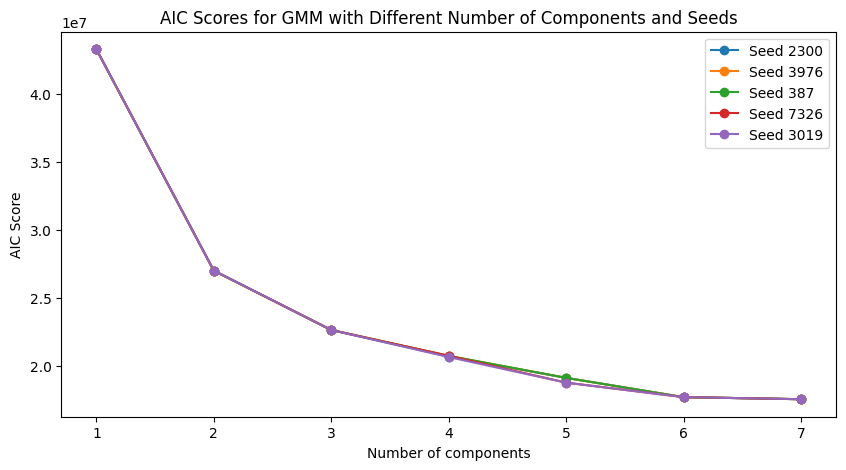

In [16]:
plt.figure(figsize=(10,5))
for i in range(ensemble_size):
    plt.plot(n_components_range, all_aic_scores[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Number of components')
plt.ylabel('AIC Score')
plt.title('AIC Scores for GMM with Different Number of Components and Seeds')
plt.legend()

In [17]:
# Choice of optimal number of clusters based on BIC
n_clusters = 6

In [18]:
gmm_0 = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seeds[0])

labels_0 = gmm_0.fit_predict(df_sampled[features])

In [19]:
df_sampled['gmm_label_6'] = labels_0

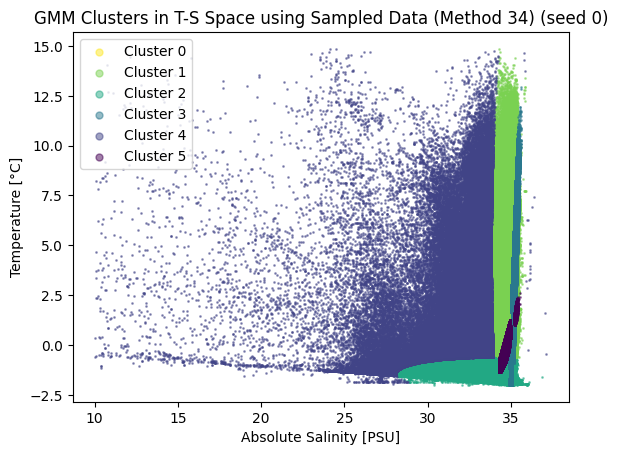

In [20]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_6'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34) (seed 0)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:626: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



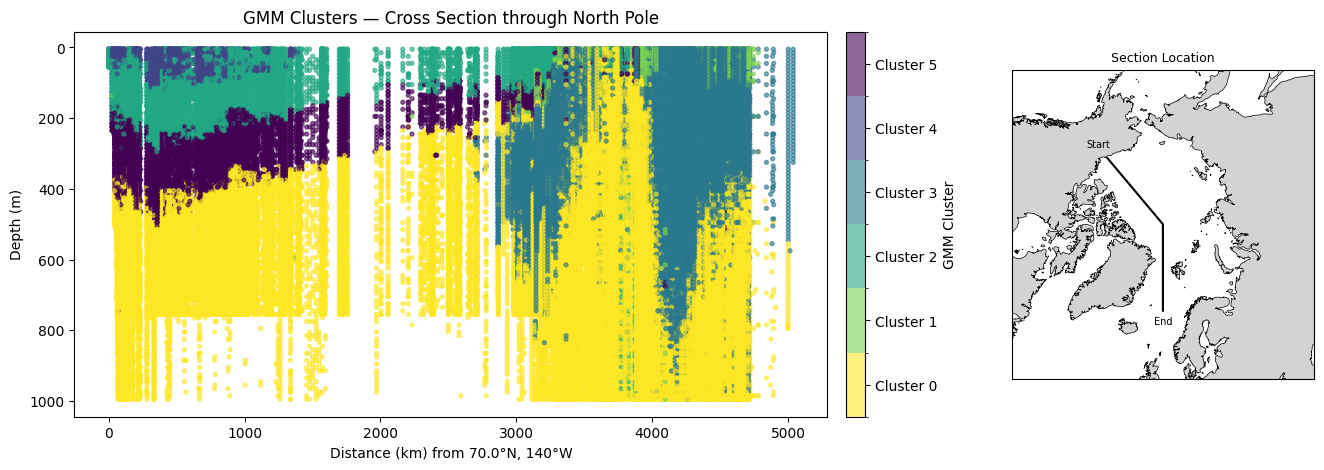

In [24]:
cross_sec_lon(df_sampled, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

In [22]:
for i in range(n_clusters):
    df_sampled['prob_cluster_'+str(i)] = gmm_0.predict_proba(df_sampled[features])[:, i]

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:859: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



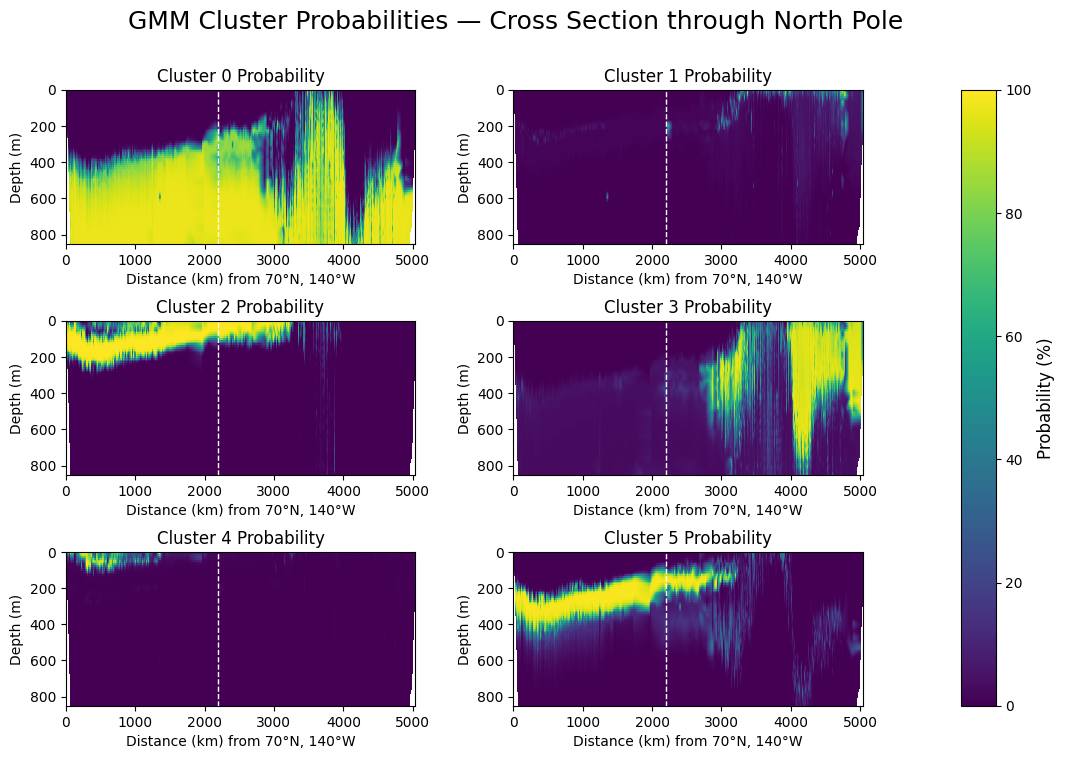

In [23]:
cross_sec_lon_prob2(df_sampled, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

In [25]:
gmms = []
labels = [] 
for i,seed in enumerate(seeds):
    gmm = GaussianMixture(
        n_components=n_clusters,          # number of clusters
        covariance_type='full',  # full cov matrix has more flexibility
        random_state=seed)
    gmm.fit(df_sampled[features])
    gmms.append(gmm)
    labels.append(gmm.predict(df_sampled[features]))

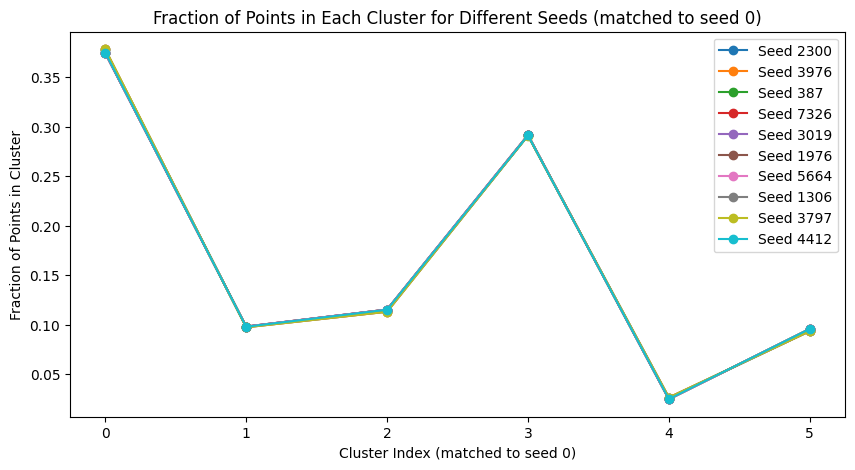

In [27]:
# Preprocess for comparrison of cluster labels across different seeds
# Clusters with similar mean T and S should be matched across different seeds
cluster_means = []
for i in range(ensemble_size):
    means = gmms[i].means_
    cluster_means.append(means)

# Match clusters across different seeds based on closest mean T and S
matched_labels = []
for i in range(ensemble_size):
    means = cluster_means[i]
    matched = np.zeros(n_clusters, dtype=int)
    for j in range(n_clusters):
        mean_T = means[j, 0]
        mean_S = means[j, 1]
        min_dist = np.inf
        match = -1
        for k in range(n_clusters):
            dist = np.sqrt((mean_T - cluster_means[0][k, 0])**2 + (mean_S - cluster_means[0][k, 1])**2)
            if dist < min_dist:
                min_dist = dist
                match = k
        matched[j] = match
    matched_labels.append(matched)

# Now matched_labels[i][j] gives the index of the cluster in seed 0 that matches cluster j in seed i
# Calculate the fraction of points in each cluster for each seed
cluster_fractions = []
for i in range(ensemble_size):
    matched = matched_labels[i]
    labels_i = labels[i]
    fractions = np.zeros(n_clusters)
    for j in range(n_clusters):
        cluster_j = np.where(labels_i == j)[0]
        matched_j = matched[j]
        fractions[matched_j] += len(cluster_j) / len(df_sampled)
    cluster_fractions.append(fractions)

# Plot the cluster fractions for each seed
plt.figure(figsize=(10,5))
for i in range(ensemble_size):
    plt.plot(range(n_clusters), cluster_fractions[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Cluster Index (matched to seed 0)') 
plt.ylabel('Fraction of Points in Cluster')
plt.title('Fraction of Points in Each Cluster for Different Seeds (matched to seed 0)')
plt.legend()
plt.show()  

In [44]:
def compute_cluster_variance(gmm_ensemble, matched_labels):
    """
    Compute variance of aligned clusters across an ensemble of GMMs.

    Parameters
    ----------
    gmm_ensemble : list
        List of fitted sklearn GaussianMixture objects.

    matched_labels : list of arrays/lists
        matched_labels[i][k] gives the original cluster index in
        gmm_ensemble[i] corresponding to common cluster k.

    Returns
    -------
    dict
        Variance statistics for each aligned cluster.
    """

    # Reorder all GMM parameters according to matched_labels
    aligned_means = []
    aligned_weights = []
    aligned_covs = []

    for gmm, labels in zip(gmm_ensemble, matched_labels):

        labels = np.asarray(labels)

        aligned_means.append(gmm.means_[labels])
        aligned_weights.append(gmm.weights_[labels])
        aligned_covs.append(gmm.covariances_[labels])

    means = np.stack(aligned_means)      # (n_models, K, D)
    weights = np.stack(aligned_weights)  # (n_models, K)
    covs = np.stack(aligned_covs)

    n_clusters = means.shape[1]

    results = {}

    for k in range(n_clusters):

        mean_var = np.var(means[:, k, :], axis=0)
        mean_var_scalar = np.mean(mean_var)

        weight_var = np.var(weights[:, k])

        cov_var = np.var(covs[:, k], axis=0)
        cov_var_scalar = np.mean(cov_var)

        results[k] = {
            "mean_variance_per_dimension": mean_var,
            "mean_variance_scalar": mean_var_scalar,
            "weight_variance": weight_var,
            "covariance_variance_matrix": cov_var,
            "covariance_variance_scalar": cov_var_scalar,
        }

    return results

In [46]:
var = compute_cluster_variance(gmms, matched_labels)

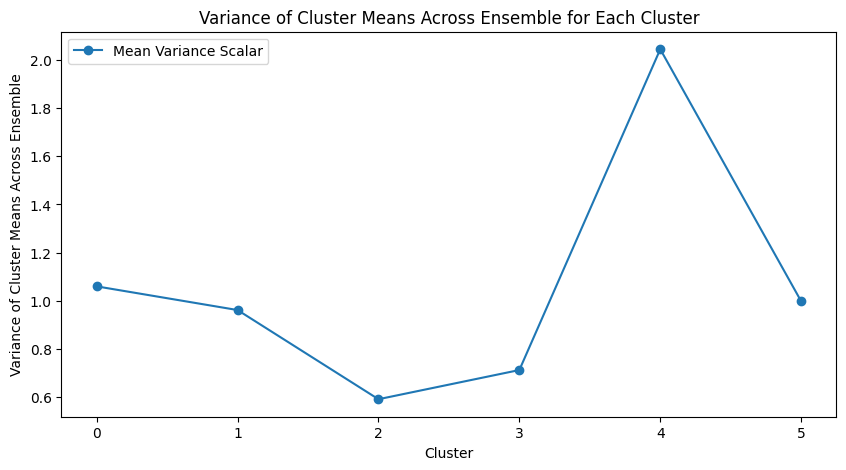

In [64]:
plt.figure(figsize=(10,5))
plt.plot(range(n_clusters), [var[k]['mean_variance_scalar'] for k in range(n_clusters)], label='Mean Variance Scalar', marker='o')
plt.xlabel('Cluster')
plt.ylabel('Variance of Cluster Means Across Ensemble')
plt.title('Variance of Cluster Means Across Ensemble for Each Cluster')
plt.legend()
plt.show()

In [68]:
def cluster_mean_dispersion(gmm_ensemble, matched_labels):

    aligned_means = []

    for gmm, labels in zip(gmm_ensemble, matched_labels):
        aligned_means.append(gmm.means_[labels])

    means = np.stack(aligned_means)  # (n_models, K, D)

    ensemble_mean = means.mean(axis=0)

    dispersion = {}

    for k in range(means.shape[1]):

        diffs = means[:, k, :] - ensemble_mean[k]
        sq_distances = np.sum(diffs**2, axis=1)

        dispersion[k] = {
            "root_mean_squared_distance": np.sqrt(np.mean(sq_distances)),
            "std_distance": np.std(np.sqrt(sq_distances))
        }

    return dispersion

In [69]:
dispersion = cluster_mean_dispersion(gmms, matched_labels)

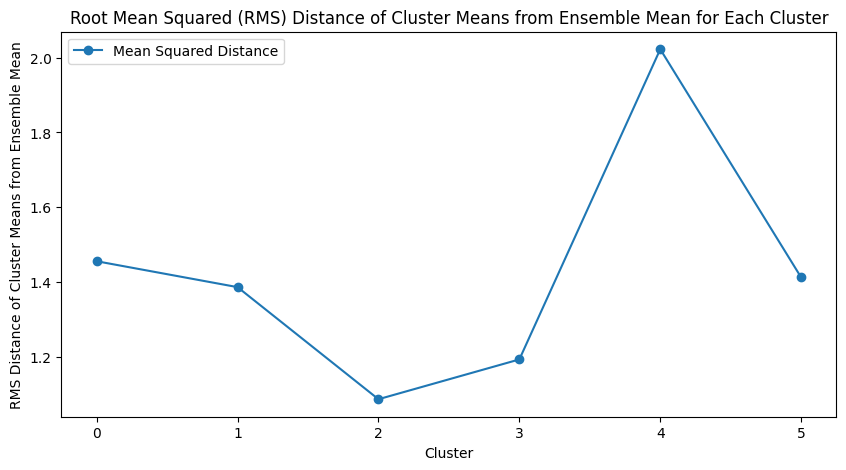

In [72]:
plt.figure(figsize=(10,5))
plt.plot(range(n_clusters), [dispersion[k]['root_mean_squared_distance'] for k in range(n_clusters)], label='Mean Squared Distance', marker='o')
plt.xlabel('Cluster')
plt.ylabel('RMS Distance of Cluster Means from Ensemble Mean')
plt.title('Root Mean Squared (RMS) Distance of Cluster Means from Ensemble Mean for Each Cluster')
plt.legend()
plt.show()

In [73]:
""" gmm ensemble give labels to all data points in df_sampled, 
then we can look at the variance of the fraction of points in each cluster 
across the ensemble, and also the variance of the mean T and S of each cluster 
across the ensemble. This will give us a sense of how stable the clusters are across 
different random seeds. We can also look at the spatial distribution of the clusters for 
different seeds to see if they are consistent in space. """

for i in range(ensemble_size):
    labels = gmms[i].predict(df_sampled[features])
    df_sampled['gmm_label_'+str(i)] = matched_labels[i][labels]

In [108]:
def cluster_overlap(df):
    """
    Compute overlap between aligned clusters across an ensemble of GMMs. 
    Create a mean cluster to use as reference.
    
    Parameters:
    - df: dataframe with columns for each GMM in the ensemble, 
        where each column contains the cluster labels for that GMM.

    Returns:
    - dict with overlap statistics for each aligned cluster.
    """

    # compute mode cluster labels across ensemble to use as reference
    mean_clusters = df[[f'gmm_label_{i}' for i in range(ensemble_size)]].mean(axis=1).round().astype(int)
    df['mean_cluster'] = mean_clusters # add mean cluster labels to dataframe

    n_clusters = len(set(df['gmm_label_0']))  # All have same number of clusters
    overlap_results = {}

    for k in range(n_clusters):

        cluster_k_mask = mean_clusters == k

        overlaps = []

        for i in range(0, ensemble_size):
            cluster_i_mask = df[f'gmm_label_{i}'] == k
            overlap_fraction = np.sum(cluster_k_mask & cluster_i_mask) / np.sum(cluster_k_mask)
            overlaps.append(overlap_fraction)

        overlap_results[k] = {
            "mean_overlap_fraction": np.mean(overlaps),
            "std_overlap_fraction": np.std(overlaps),
            "overlap_fractions": overlaps
        }

    return overlap_results, df

In [109]:
overlap, df_sampled = cluster_overlap(df_sampled)

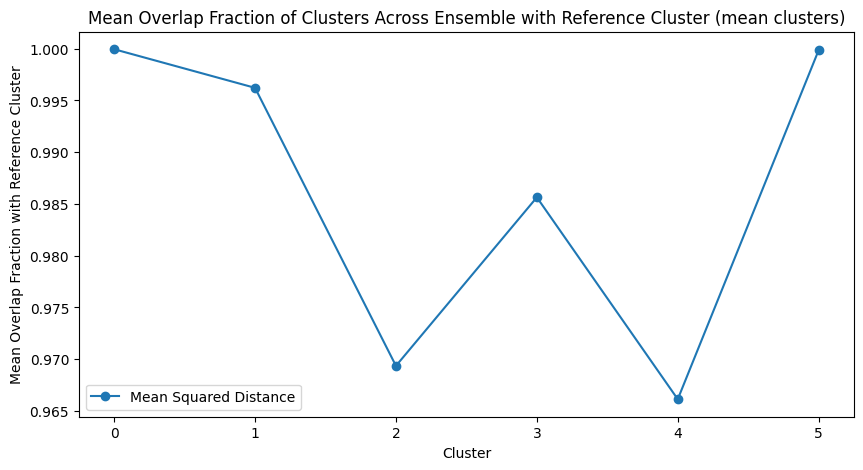

In [110]:
plt.figure(figsize=(10,5))
plt.plot(range(n_clusters), [overlap[k]['mean_overlap_fraction'] for k in range(n_clusters)], label='Mean Squared Distance', marker='o')
plt.xlabel('Cluster')
plt.ylabel('Mean Overlap Fraction with Reference Cluster')
plt.title('Mean Overlap Fraction of Clusters Across Ensemble with Reference Cluster (mean clusters)')
plt.legend()
plt.show()

In [113]:
df_sampled_copy = df_sampled.copy()
df_sampled_copy['gmm_label_6'] = df_sampled_copy['mean_cluster']

In [121]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Geod
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

def compute_great_circle_distance_km(lat_ref, lon_ref, lats, lons):
    """Compute distance in km from a reference point along a great circle."""
    geod = Geod(ellps='WGS84')
    _, _, dist_m = geod.inv(
        np.full(len(lats), lon_ref),
        np.full(len(lats), lat_ref),
        lons,
        lats
    )
    return dist_m / 1000.0

def cross_sec_lon(df_sampled, n_clusters, lon_value, tol=0.5, start_lat=70.0, start_lon=-140.0, max_depth=850,
                depth_bin_size=10, dist_bin_size=2.2):

    # Primary slice from start_lon and secondary for lon_value intersecting at the pole
    df_primary = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= start_lon - tol) &
        (df_sampled['Longitude_[deg_E]'] <= start_lon + tol)
    ].copy()

    df_antipodal = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_sampled['Longitude_[deg_E]'] <= lon_value + tol)
    ].copy()

    df_lon_slice = pd.concat([df_primary, df_antipodal], ignore_index=True)

    # Compute great-circle distance from start point
    df_lon_slice['dist_km'] = compute_great_circle_distance_km(
        start_lat, start_lon,
        df_lon_slice['Latitude_[deg_N]'].values,
        df_lon_slice['Longitude_[deg_E]'].values
    )

    # Bin coordinates
    df_lon_slice['depth_bin'] = (
        np.floor(df_lon_slice['Depth_[m]'] / depth_bin_size)
        * depth_bin_size
    )

    df_lon_slice['dist_bin'] = (
        np.floor(df_lon_slice['dist_km'] / dist_bin_size)
        * dist_bin_size
    )

    # Average probabilities within bins
    prob_cols = [f'gmm_label_6' for i in range(n_clusters)]

    df_binned = (
        df_lon_slice
        .groupby(['dist_bin', 'depth_bin'])[prob_cols]
        .mean()
        .reset_index()
    )

    # Regular plotting grid
    xi = np.arange(
        df_binned['dist_bin'].min(),
        df_binned['dist_bin'].max(),
        dist_bin_size
    )

    yi = np.arange(
        0,
        max_depth + depth_bin_size,
        depth_bin_size
    )

    XI, YI = np.meshgrid(xi, yi)

    # ── Colormap (GMM labels) ─────────────────────────────────────────────────
    n = n_clusters
    base_cmap = plt.cm.viridis_r
    colors = base_cmap(np.linspace(0, 1, n))
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, n + 0.5, 1), cmap.N)

    # ── Side-by-side layout ───────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.05)

    ax = fig.add_subplot(gs[0])
    ax_map = fig.add_subplot(gs[1], projection=ccrs.NorthPolarStereo())

    # ── Cross-section scatter plot ────────────────────────────────────────────
    ZI = griddata(
            (
                df_binned['dist_bin'],
                df_binned['depth_bin']
            ),
            df_binned['gmm_label_6'] * 100,
            (XI, YI),
            method='linear'
        )
    ZI = gaussian_filter(ZI, sigma=1.0)

    pcm = ax.pcolormesh(
            XI,
            YI,
            ZI,
            shading='auto',
            cmap='viridis',
            vmin=0,
            vmax=100)
    
    sc = ax.scatter(
        df_lon_slice['dist_km'],
        df_lon_slice['Depth_[m]'],
        c=df_lon_slice['gmm_label_'+str(n)],
        cmap=cmap,
        norm=norm,
        s=8,
        alpha=0.6
    )

    ax.invert_yaxis()
    ax.set_xlabel(f'Distance (km) from {start_lat}°N, {abs(start_lon)}°W')
    ax.set_ylabel('Depth (m)')
    ax.set_title('GMM Clusters — Cross Section through North Pole')

    # Discrete colorbar
    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_ticks(range(n))
    cbar.set_ticklabels([f'Cluster {i}' for i in range(n)])
    cbar.set_label('GMM Cluster')

    # ── Polar map ─────────────────────────────────────────────────────────────
    ax_map.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_map.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)

    # Section track: start → pole → antipodal end
    end_lat = start_lat
    end_lon = lon_value
    lats_track = [start_lat, 90.0, end_lat]
    lons_track = [start_lon, lon_value, end_lon]

    ax_map.plot(lons_track, lats_track,
                color='black', linewidth=1.5,
                transform=ccrs.Geodetic(), zorder=3)

    ax_map.text(start_lon, start_lat - 3, 'Start',
                transform=ccrs.PlateCarree(),
                fontsize=7, ha='center', color='black')
    ax_map.text(end_lon, end_lat - 3, 'End',
                transform=ccrs.PlateCarree(),
                fontsize=7, ha='center', color='black')

    ax_map.set_title('Section Location', fontsize=9)

    plt.tight_layout()
    plt.show()

ValueError: For X (2291) and Y (87) with flat shading, A should have shape (86, 2290, 3) or (86, 2290, 4) or (86, 2290) or (196940,), not (86, 2290, 6)

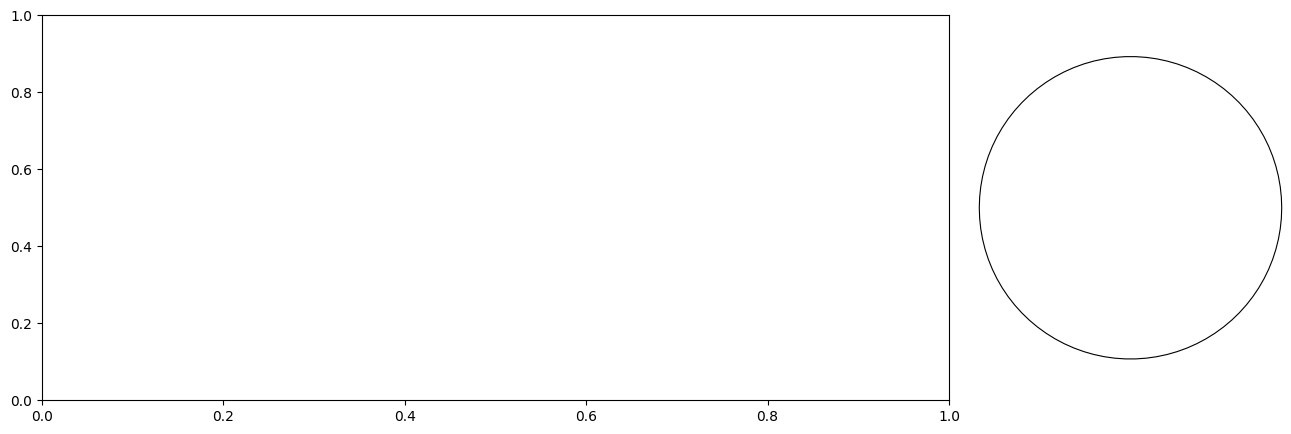

In [122]:
cross_sec_lon(df_sampled, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140.0)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_67135/1133101004.py:100: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



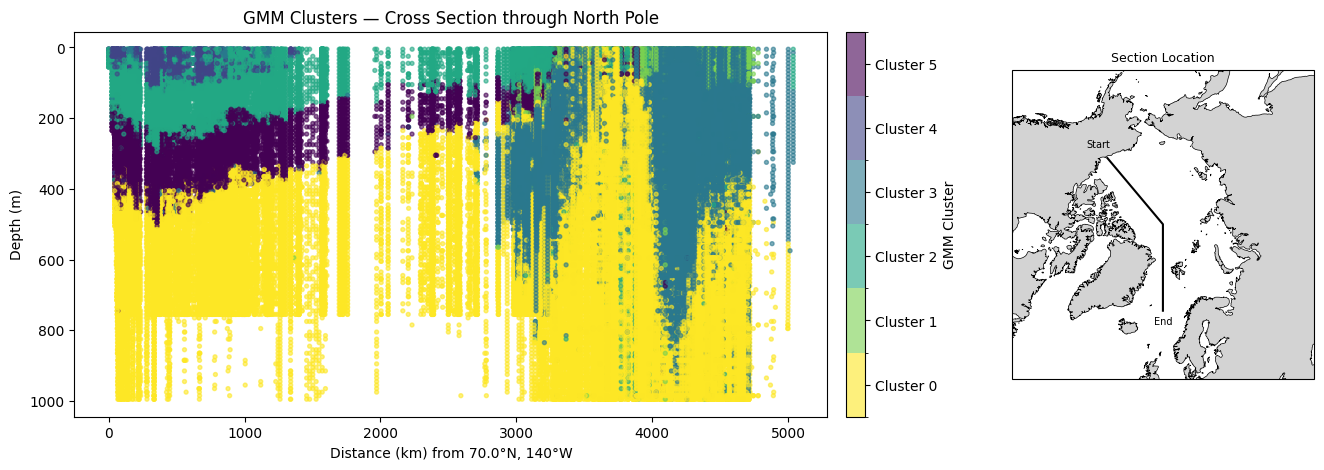

In [120]:
# plot cross section of mean clusters
cross_sec_lon(df_sampled_copy, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

In [106]:
# plot cross section of difference between mean clusters and seed 0 clusters
df_sampled_copy['gmm_label_6'] = df_sampled_copy['mean_cluster']-df_sampled_copy['gmm_label_0']

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:626: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



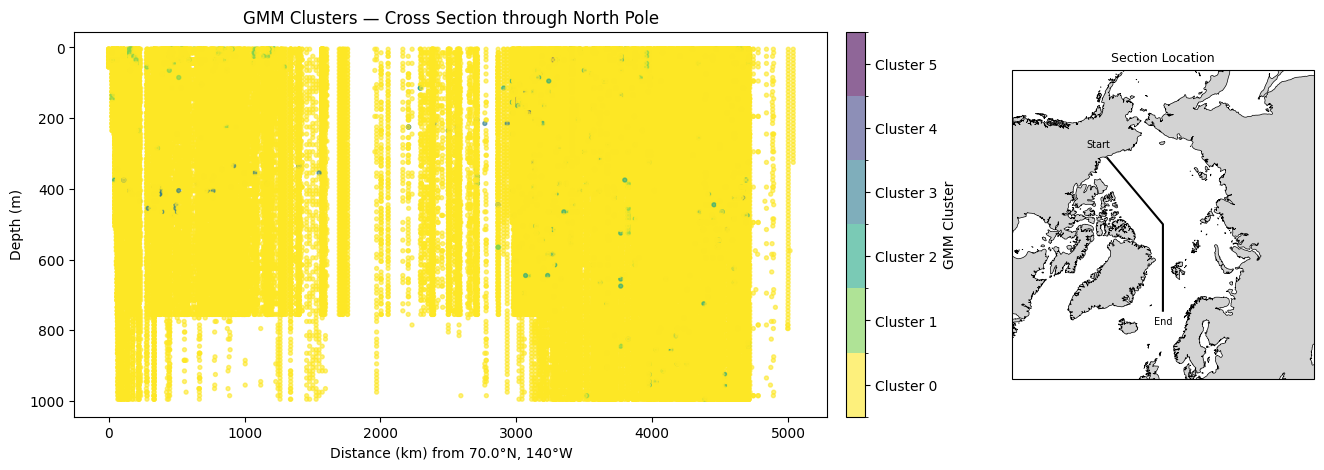

In [107]:
cross_sec_lon(df_sampled_copy, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

In [123]:
# find the probabilities of the mean clusters
for i in range(ensemble_size):
    for j in range(n_clusters):
        df_sampled_copy[f'prob_cluster_{j}_gmm_{i}'] = gmms[i].predict_proba(df_sampled_copy[features])[:, j]

for j in range(n_clusters):
    df_sampled_copy[f'prob_mean_cluster_{j}'] = df_sampled_copy[[f'prob_cluster_{j}_gmm_{i}' for i in range(ensemble_size)]].mean(axis=1)

In [125]:
df_copy = df_sampled_copy.copy()
for i in range(n_clusters):
    df_copy['prob_cluster_'+str(i)] = df_sampled_copy[f'prob_mean_cluster_{i}']

In [147]:
df_copy['prob_cluster_0_gmm_2'].head()

0    6.589817e-06
1    2.490919e-10
2    1.225586e-13
3    1.176999e-05
4    9.787242e-06
Name: prob_cluster_0_gmm_2, dtype: float64

: 

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:859: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



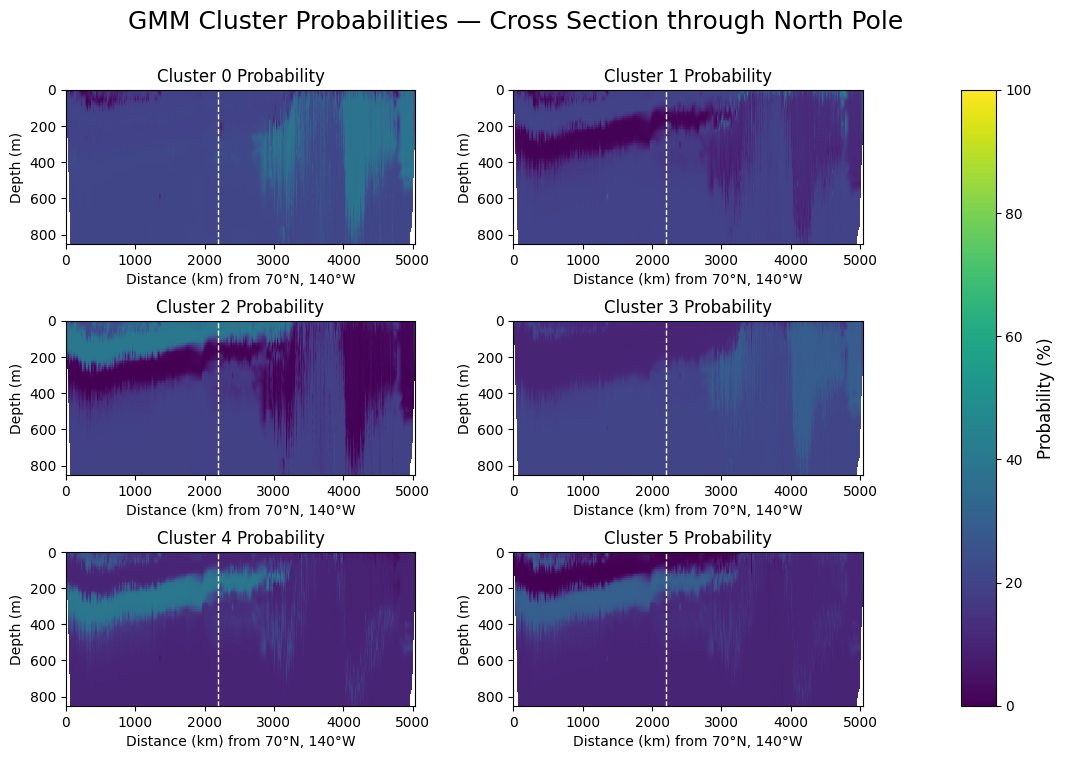

In [126]:
cross_sec_lon_prob2(df_copy, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

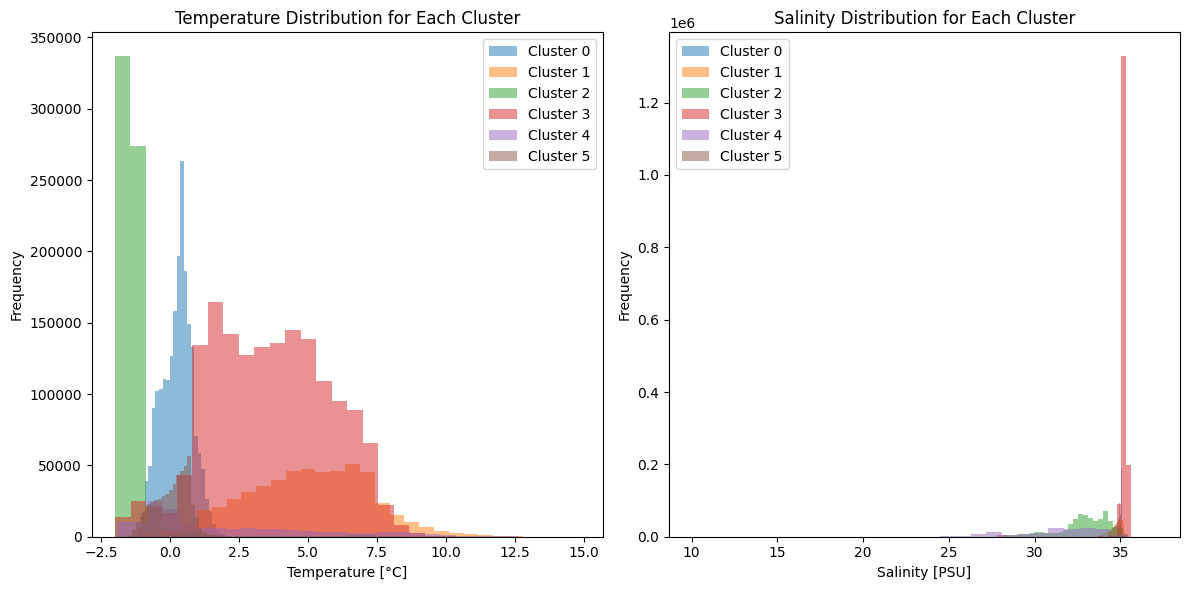

In [124]:
# Diagnostic plots
plt.figure(figsize=(12, 6))

# Temperature distribution for each cluster
plt.subplot(1, 2, 1)
for i in range(n_clusters):
    mask = df_sampled_copy['gmm_label_6'] == i
    plt.hist(df_sampled_copy.loc[mask, 'Conservative_Temperature_[deg_C]'], bins=30, alpha=0.5, label=f'Cluster {i}')
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Temperature Distribution for Each Cluster")
plt.legend()

# Salinity distribution for each cluster
plt.subplot(1, 2, 2)
for i in range(n_clusters):
    mask = df_sampled_copy['gmm_label_6'] == i
    plt.hist(df_sampled_copy.loc[mask, 'Absolute_Salinity_[PSU]'], bins=30, alpha=0.5, label=f'Cluster {i}')
plt.xlabel("Salinity [PSU]")
plt.ylabel("Frequency")
plt.title("Salinity Distribution for Each Cluster")
plt.legend()

plt.tight_layout()
plt.show()


In [127]:
from matplotlib.ticker import ScalarFormatter

def feature_histograms(df, feat_col='Conservative_Temperature_[deg_C]', label_col='gmm_label_6', feature='Temperature [°C]'):
    n_clusters = df[label_col].nunique()
    colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))

    fig, axes = plt.subplots(n_clusters, 1, figsize=(22, 15), sharex=True)

    if n_clusters == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        cluster_data = df[df[label_col] == i][feat_col]
        ax.hist(cluster_data, bins=50, alpha=0.5, color=colors[i], label=f'Cluster {i}')
        ax.legend()
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    fig.supxlabel(feature)
    fig.supylabel('Frequency', x=0.01)
    fig.suptitle(feature + ' Histograms by GMM Cluster')

    x_min = df[feat_col].min()
    x_max = df[feat_col].max()
    axes[0].set_xlim(x_min, x_max)

    plt.tight_layout()
    plt.show()

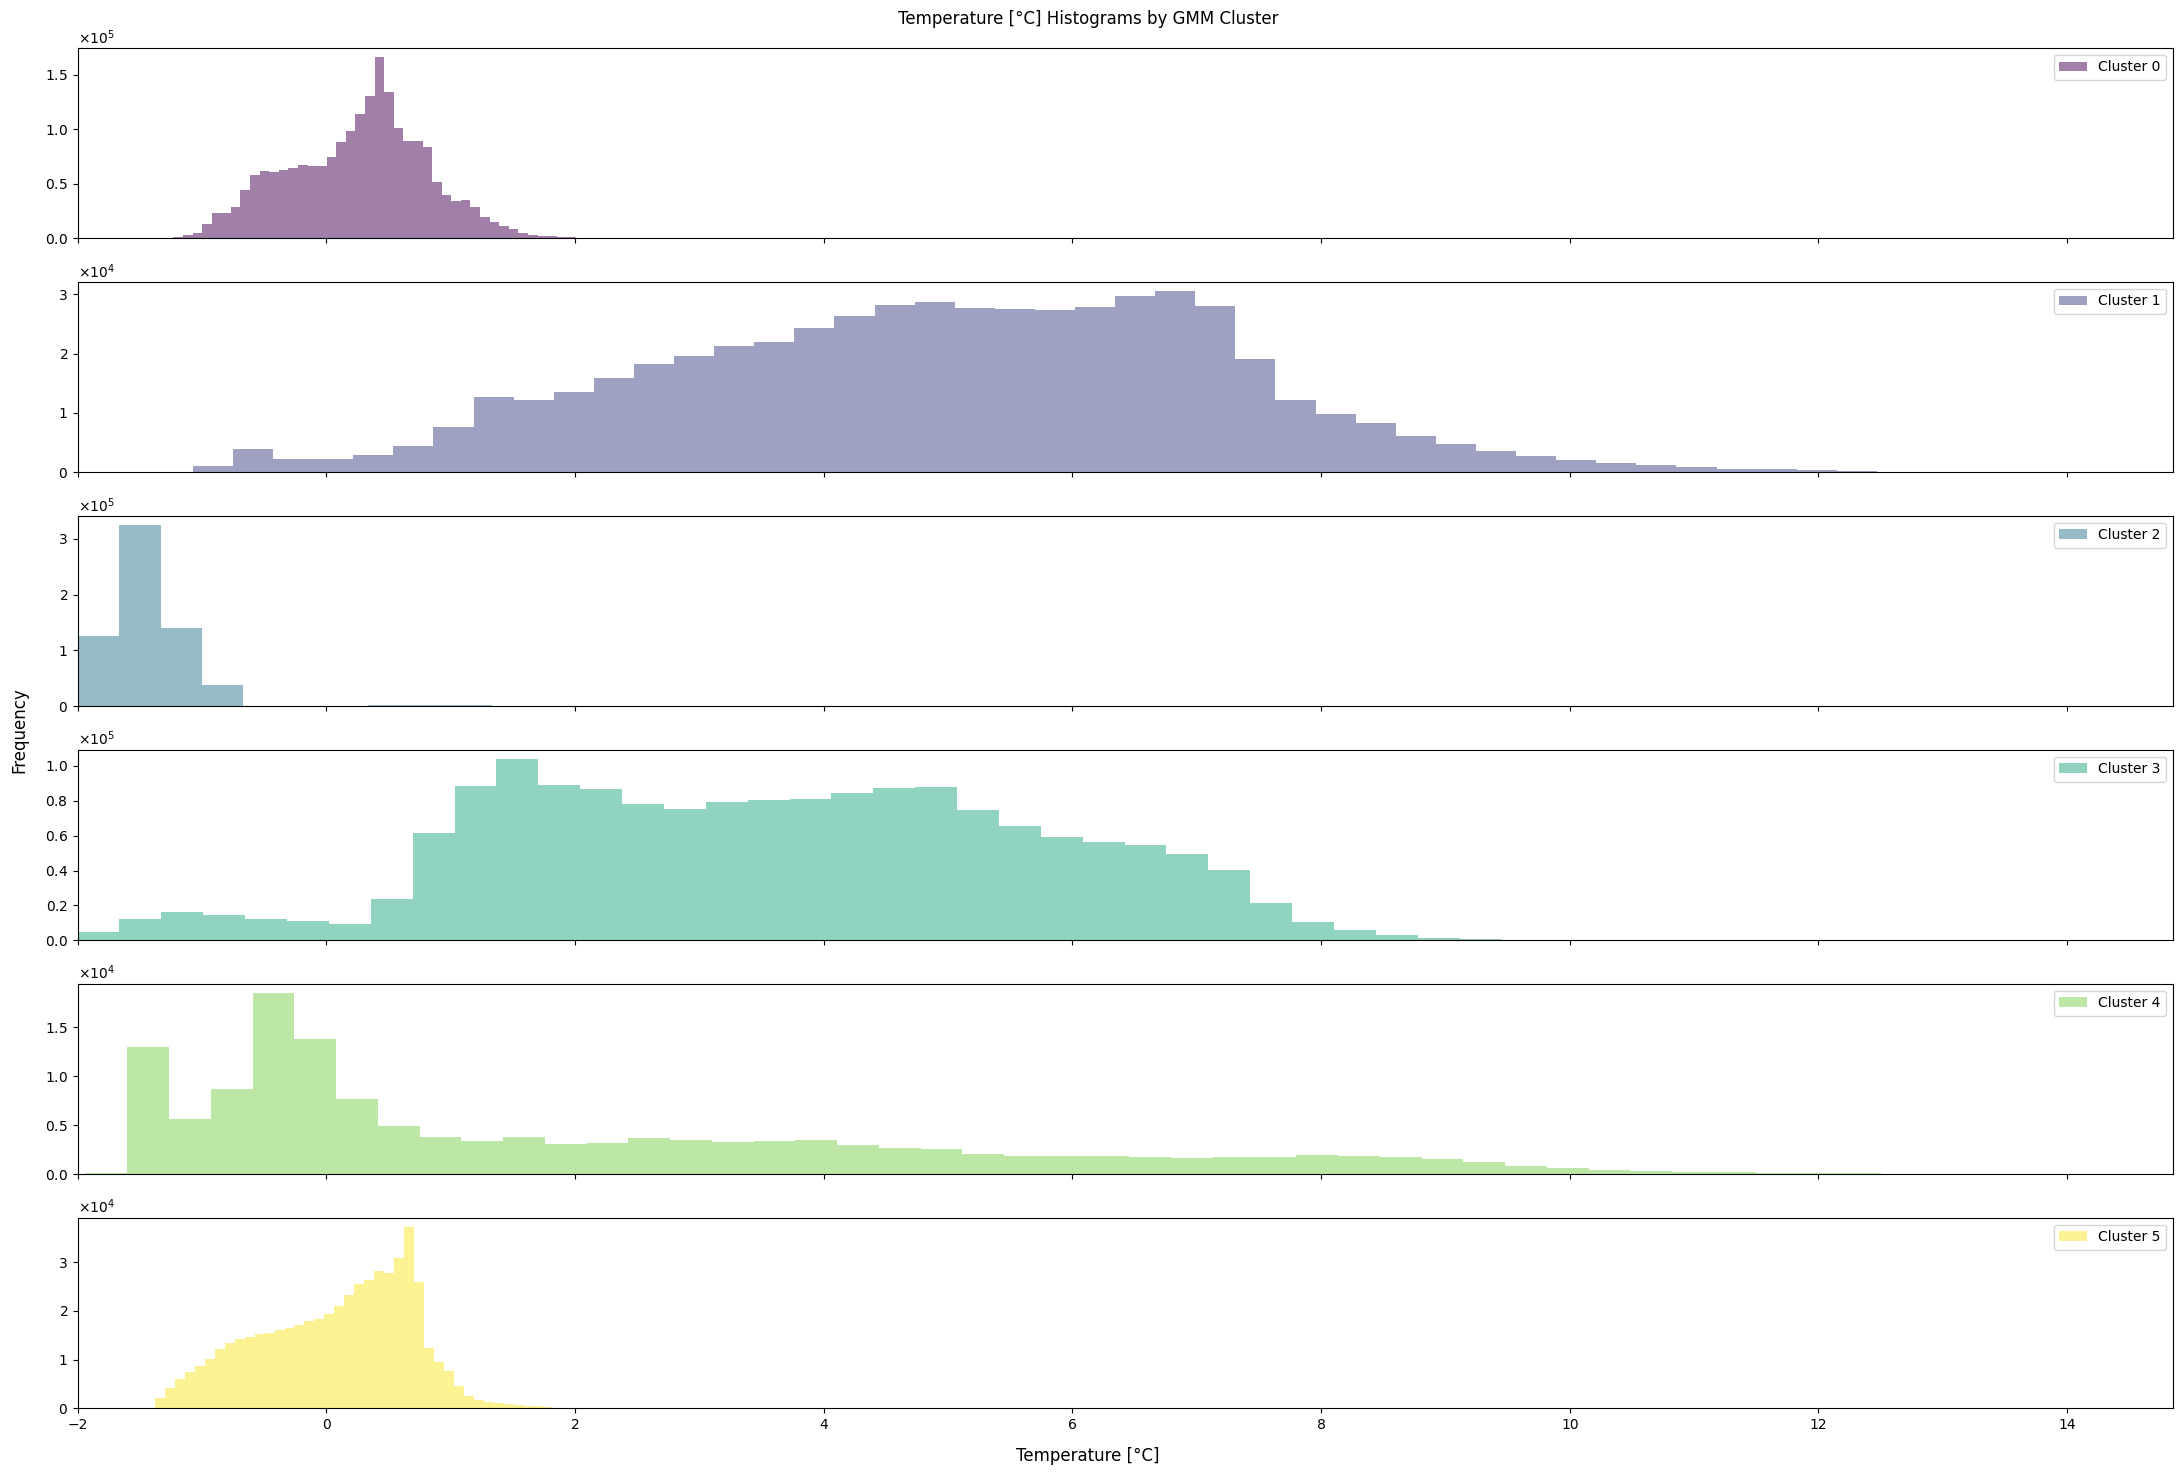

In [129]:
feature_histograms(df_sampled_copy, feat_col='Conservative_Temperature_[deg_C]', label_col='gmm_label_6', feature='Temperature [°C]')

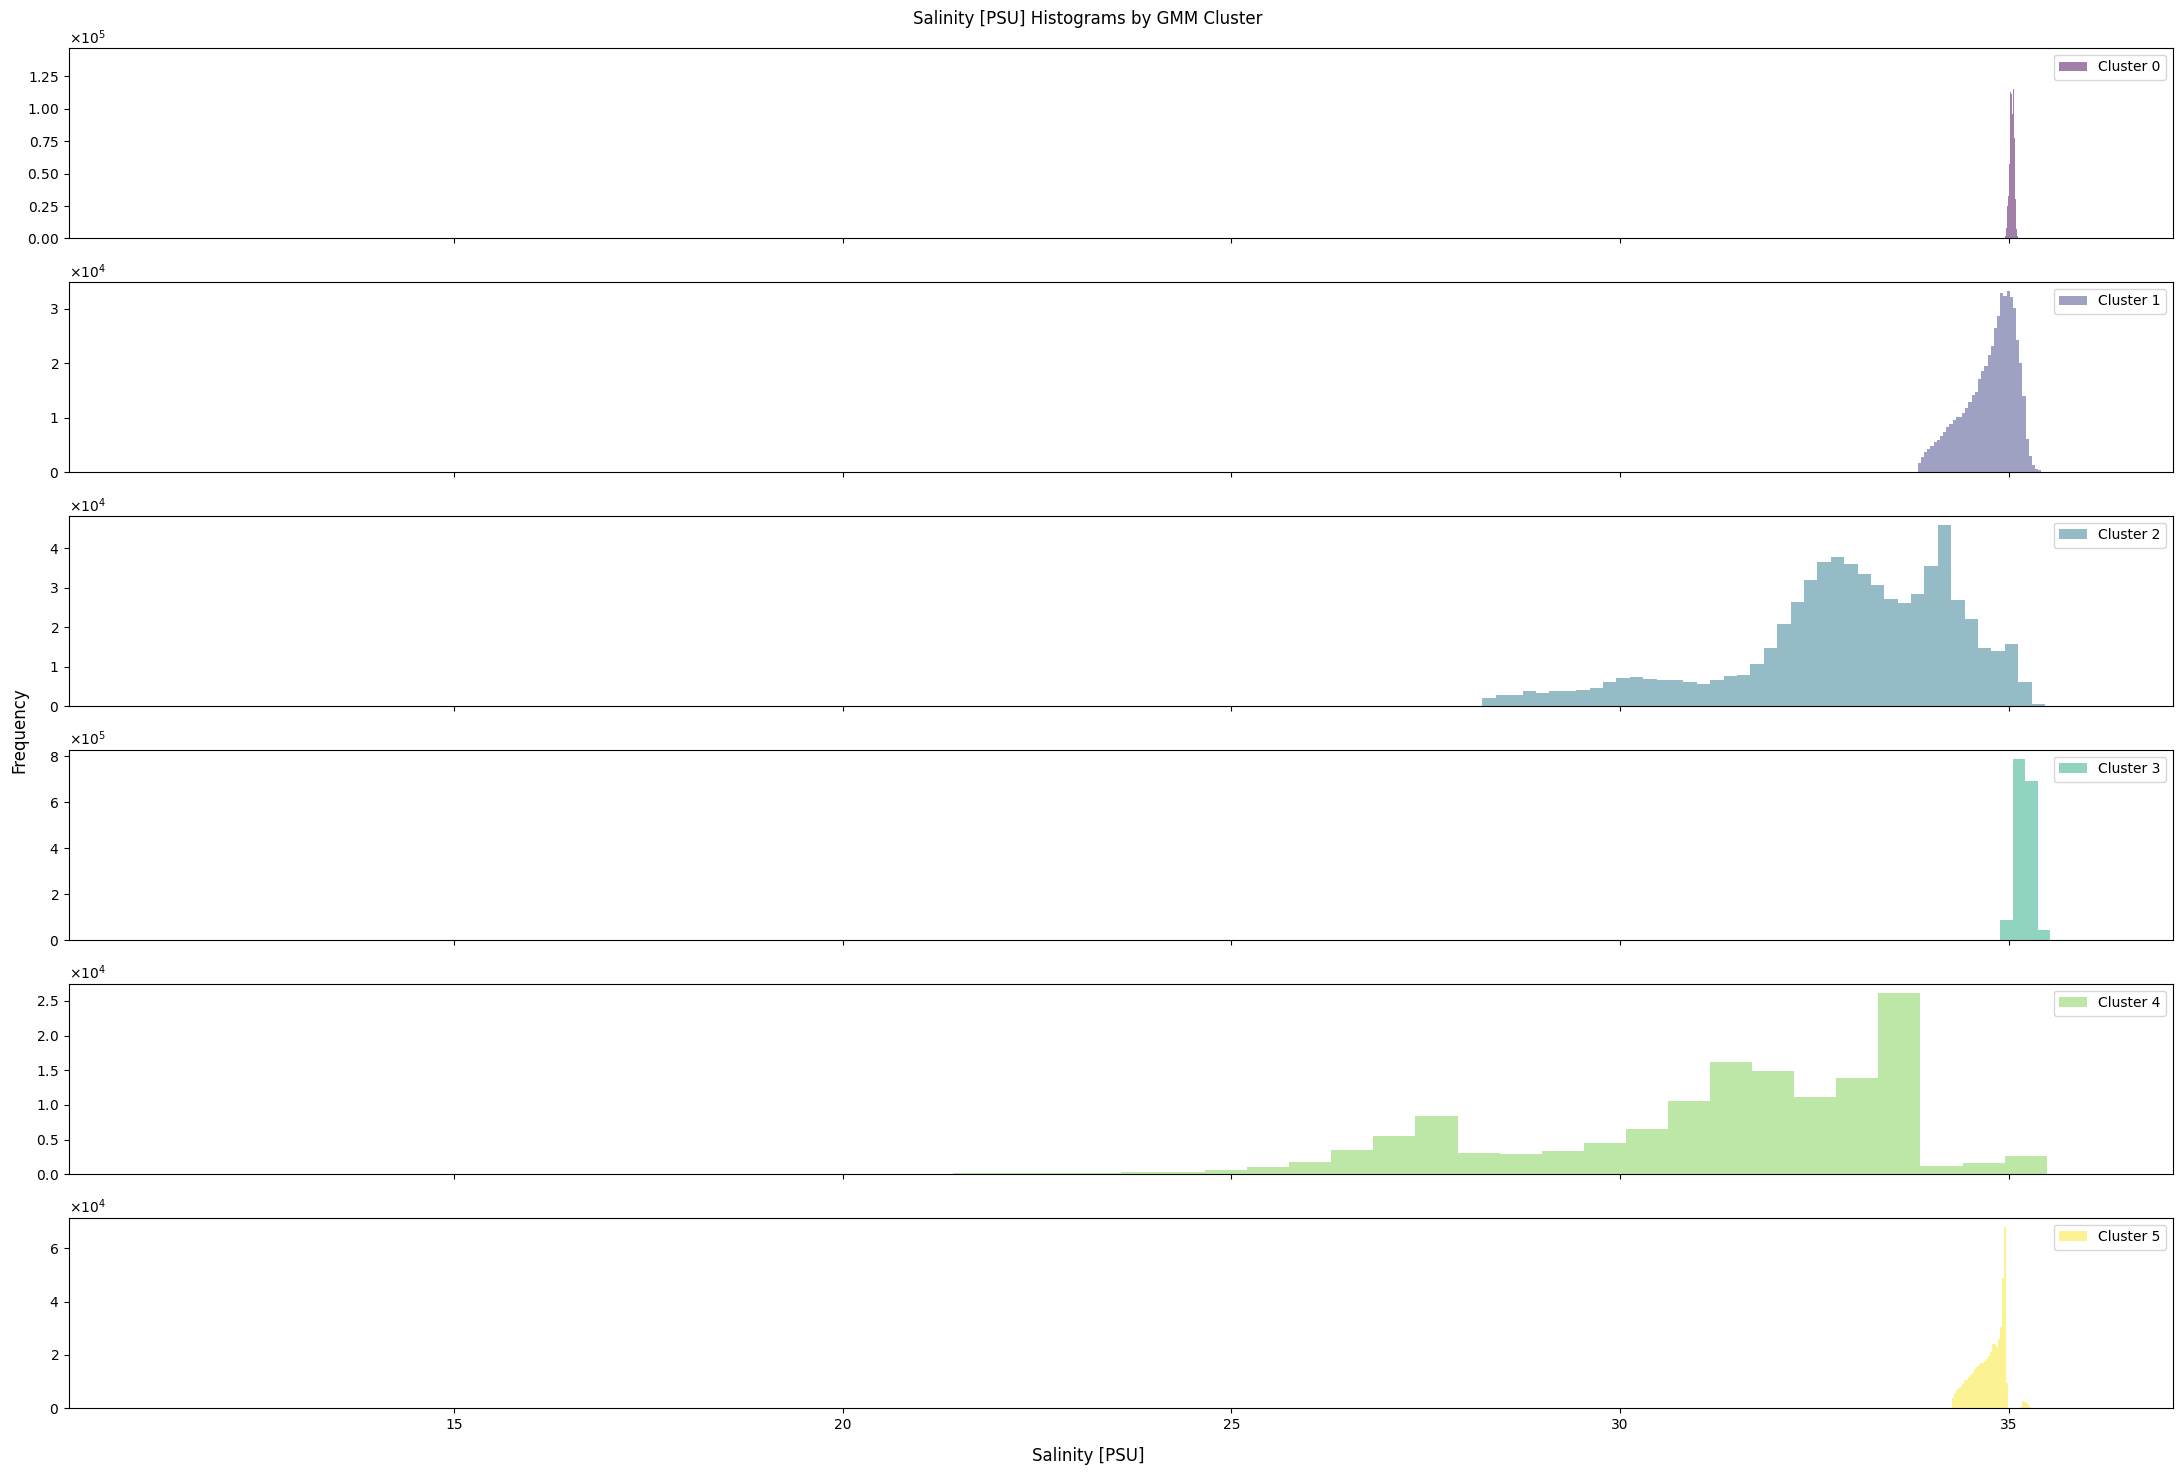

In [130]:
feature_histograms(df_sampled_copy, feat_col='Absolute_Salinity_[PSU]', label_col='gmm_label_6', feature='Salinity [PSU]')